In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Load inventory SKU analysis created in SQL
inventory = pd.read_csv("inventory_sku_analysis.csv")

# Check dataset structure
print("Dataset shape:", inventory.shape)
inventory.head()

Dataset shape: (14143, 13)


,Store_ID,Store_Name,Store_City,Store_Location,Product_ID,Product_Name,Product_Category,Stock_On_Hand,Units_Sold,Revenue,COGS,Gross_Profit,Stock_to_Sales_Ratio
0,1,Maple Street Toys Louisville 1,"Louisville, KY",Downtown,1,Classic Board Game,Building Blocks,24,27,631.53,320.22,311.31,0.8889
1,1,Maple Street Toys Louisville 1,"Louisville, KY",Downtown,2,Pro Puzzle Pack,Arts & Crafts,32,55,854.70,459.80,394.90,0.5818
2,1,Maple Street Toys Louisville 1,"Louisville, KY",Downtown,3,Retro Princess Doll,Building Blocks,25,61,677.10,483.73,193.37,0.4098
3,1,Maple Street Toys Louisville 1,"Louisville, KY",Downtown,4,Deluxe Builder Set,Baby & Toddler,32,36,595.44,285.48,309.96,0.8889
4,1,Maple Street Toys Louisville 1,"Louisville, KY",Downtown,5,Smart Art Kit,Plush,12,31,911.71,666.81,244.90,0.3871


In [2]:
# Calculate overall inventory and sales metrics
inventory_overview = {
    "Total Stock On Hand": inventory["Stock_On_Hand"].sum(),
    "Total Units Sold": inventory["Units_Sold"].sum(),
    "Total Revenue": inventory["Revenue"].sum(),
    "Number of Store-Product Combinations": len(inventory)
}

inventory_overview

{'Total Stock On Hand': np.int64(338993),
 'Total Units Sold': np.int64(567270),
 'Total Revenue': np.float64(9862933.25),
 'Number of Store-Product Combinations': 14143}

In [3]:
# Calculate stock-to-sales ratio using the inventory snapshot and annual unit sales
inventory["Stock_to_Sales_Ratio"] = (
    inventory["Stock_On_Hand"] /
    inventory["Units_Sold"].replace(0, np.nan)
)

# Calculate annual unit sales per unit of current stock
inventory["Sales_to_Stock_Ratio"] = (
    inventory["Units_Sold"] /
    inventory["Stock_On_Hand"].replace(0, np.nan)
)

inventory[
    [
        "Store_ID",
        "Product_ID",
        "Stock_On_Hand",
        "Units_Sold",
        "Stock_to_Sales_Ratio",
        "Sales_to_Stock_Ratio"
    ]
].head()

,Store_ID,Product_ID,Stock_On_Hand,Units_Sold,Stock_to_Sales_Ratio,Sales_to_Stock_Ratio
0,1,1,24,27,0.888889,1.125000
1,1,2,32,55,0.581818,1.718750
2,1,3,25,61,0.409836,2.440000
3,1,4,32,36,0.888889,1.125000
4,1,5,12,31,0.387097,2.583333


In [4]:
# Calculate the correlation between current stock and annual unit sales
stock_sales_correlation = inventory[
    ["Stock_On_Hand", "Units_Sold"]
].corr().iloc[0, 1]

print(f"Stock vs annual units sold correlation: {stock_sales_correlation:.3f}")

Stock vs annual units sold correlation: 0.178


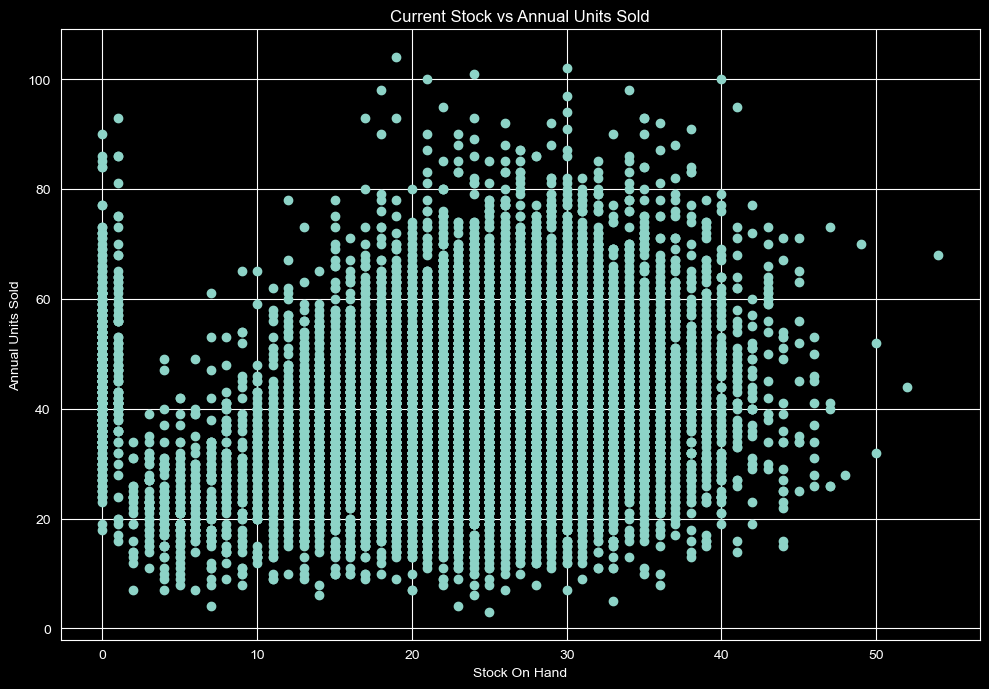

In [5]:
# Plot current stock against annual units sold
plt.figure(figsize=(10, 7))

plt.scatter(
    inventory["Stock_On_Hand"],
    inventory["Units_Sold"]
)

plt.title("Current Stock vs Annual Units Sold")
plt.xlabel("Stock On Hand")
plt.ylabel("Annual Units Sold")
plt.tight_layout()
plt.show()

In [8]:
# Examine the distribution of the sales-to-stock ratio
inventory["Sales_to_Stock_Ratio"].describe()
# Calculate quartile thresholds for inventory risk segmentation
low_stock_threshold = inventory["Sales_to_Stock_Ratio"].quantile(0.75)
high_stock_threshold = inventory["Sales_to_Stock_Ratio"].quantile(0.25)

print(f"High sales-to-stock threshold: {low_stock_threshold:.2f}")
print(f"Low sales-to-stock threshold: {high_stock_threshold:.2f}")
# Classify inventory positions based on annual sales relative to current stock
def classify_inventory(row):
    ratio = row["Sales_to_Stock_Ratio"]

    if pd.isna(ratio):
        return "No Sales"
    elif ratio >= low_stock_threshold:
        return "High Stock Pressure"
    elif ratio <= high_stock_threshold:
        return "Potential Overstock"
    else:
        return "Balanced"

inventory["Inventory_Risk"] = inventory.apply(
    classify_inventory,
    axis=1
)

# Display inventory risk distribution
inventory["Inventory_Risk"].value_counts()

High sales-to-stock threshold: 2.12
Low sales-to-stock threshold: 1.22


Inventory_Risk
Balanced               6894
High Stock Pressure    3469
Potential Overstock    3459
No Sales                321
Name: count, dtype: int64

In [9]:
# Identify store-product combinations with the highest stock pressure
high_stock_pressure = (
    inventory[
        inventory["Inventory_Risk"] == "High Stock Pressure"
    ]
    .sort_values(
        "Sales_to_Stock_Ratio",
        ascending=False
    )
)

high_stock_pressure[
    [
        "Store_ID",
        "Product_ID",
        "Stock_On_Hand",
        "Units_Sold",
        "Sales_to_Stock_Ratio",
        "Inventory_Risk"
    ]
].head(20)

,Store_ID,Product_ID,Stock_On_Hand,Units_Sold,Sales_to_Stock_Ratio,Inventory_Risk
3607,31,118,1,93,93.0,High Stock Pressure
2822,24,170,1,86,86.0,High Stock Pressure
9959,85,61,1,86,86.0,High Stock Pressure
9973,85,83,1,81,81.0,High Stock Pressure
4147,36,26,1,75,75.0,High Stock Pressure
9968,85,76,1,75,75.0,High Stock Pressure
9924,85,4,1,73,73.0,High Stock Pressure
7550,65,89,1,70,70.0,High Stock Pressure
4168,36,50,1,68,68.0,High Stock Pressure
100,1,137,1,68,68.0,High Stock Pressure


In [10]:
# Identify store-product combinations with potential overstock
potential_overstock = (
    inventory[
        inventory["Inventory_Risk"] == "Potential Overstock"
    ]
    .sort_values(
        "Sales_to_Stock_Ratio",
        ascending=True
    )
)

potential_overstock[
    [
        "Store_ID",
        "Product_ID",
        "Stock_On_Hand",
        "Units_Sold",
        "Sales_to_Stock_Ratio",
        "Inventory_Risk"
    ]
].head(20)

,Store_ID,Product_ID,Stock_On_Hand,Units_Sold,Sales_to_Stock_Ratio,Inventory_Risk
10996,94,36,25,3,0.120000,Potential Overstock
6910,59,151,33,5,0.151515,Potential Overstock
7726,66,175,23,4,0.173913,Potential Overstock
11897,101,110,36,8,0.222222,Potential Overstock
10668,91,72,30,7,0.233333,Potential Overstock
13355,113,172,24,6,0.250000,Potential Overstock
2914,25,123,26,7,0.269231,Potential Overstock
4700,40,151,36,10,0.277778,Potential Overstock
12555,106,180,35,10,0.285714,Potential Overstock
527,5,93,28,8,0.285714,Potential Overstock


In [17]:
# Load store-level inventory risk analysis created in SQL
inventory_store = pd.read_csv("inventory_store_risk.csv")

# Check the structure and column names
print("Dataset shape:", inventory_store.shape)
print("\nColumns:")
print(inventory_store.columns.tolist())

print("\nFirst 5 rows:")
display(inventory_store.head())

# Load store-level inventory risk analysis created in SQL
inventory_store = pd.read_csv("inventory_store_risk.csv")

# Display the dataset structure
print("Dataset shape:", inventory_store.shape)
print("\nColumns:")
print(inventory_store.columns.tolist())

# Automatically identify likely inventory-related columns
inventory_columns = [
    col for col in inventory_store.columns
    if any(keyword in col.lower() for keyword in ["stock", "inventory"])
]

print("\nInventory-related columns:")
print(inventory_columns)

# Display the complete store-level analysis
display(inventory_store.head(10))

Dataset shape: (120, 7)

Columns:
['Store_ID', 'Store_Name', 'Store_City', 'Store_Location', 'Total_SKUs', 'Replenishment_Risk_SKUs', 'Overstock_Risk_SKUs']

First 5 rows:


,Store_ID,Store_Name,Store_City,Store_Location,Total_SKUs,Replenishment_Risk_SKUs,Overstock_Risk_SKUs
0,85,Cedar Toy Corner Montgomery 1,"Montgomery, AL",Downtown,101,20,0
1,60,Wonderland Toys Scottsdale 1,"Scottsdale, AZ",Downtown,104,13,0
2,24,Playtime Emporium Los Angeles 1,"Los Angeles, CA",Downtown,134,12,2
3,51,Bright Star Toy Shop Birmingham 1,"Birmingham, AL",Downtown,129,11,1
4,17,Mini Makers Asheville 1,"Asheville, NC",Downtown,110,11,0


Dataset shape: (120, 7)

Columns:
['Store_ID', 'Store_Name', 'Store_City', 'Store_Location', 'Total_SKUs', 'Replenishment_Risk_SKUs', 'Overstock_Risk_SKUs']

Inventory-related columns:
['Overstock_Risk_SKUs']


,Store_ID,Store_Name,Store_City,Store_Location,Total_SKUs,Replenishment_Risk_SKUs,Overstock_Risk_SKUs
0,85,Cedar Toy Corner Montgomery 1,"Montgomery, AL",Downtown,101,20,0
1,60,Wonderland Toys Scottsdale 1,"Scottsdale, AZ",Downtown,104,13,0
2,24,Playtime Emporium Los Angeles 1,"Los Angeles, CA",Downtown,134,12,2
3,51,Bright Star Toy Shop Birmingham 1,"Birmingham, AL",Downtown,129,11,1
4,17,Mini Makers Asheville 1,"Asheville, NC",Downtown,110,11,0
5,115,Mountain Trail Toys Pittsburgh 1,"Pittsburgh, PA",Downtown,132,9,2
6,1,Maple Street Toys Louisville 1,"Louisville, KY",Downtown,135,8,0
7,31,Dinosaur Dreams Toys Glendale 1,"Glendale, AZ",Downtown,103,8,0
8,34,Sunshine Toy Store Arlington 1,"Arlington, TX",Downtown,129,8,0
9,99,City Lights Toys Stockton 1,"Stockton, CA",Downtown,108,7,4


In [18]:
# Load category-level inventory risk analysis created in SQL
inventory_category = pd.read_csv("inventory_category_risk.csv")

# Display the dataset structure
print("Dataset shape:", inventory_category.shape)
print("\nColumns:")
print(inventory_category.columns.tolist())

print("\nFirst 10 rows:")
display(inventory_category.head(10))

Dataset shape: (16, 4)

Columns:
['Product_Category', 'Total_SKUs', 'Replenishment_Risk_SKUs', 'Overstock_Risk_SKUs']

First 10 rows:


,Product_Category,Total_SKUs,Replenishment_Risk_SKUs,Overstock_Risk_SKUs
0,Toy Vehicles,1202,19,36
1,Arts & Crafts,1249,18,43
2,Baby & Toddler,1167,18,40
3,Outdoor Play,1055,14,33
4,Building Blocks,810,14,21
5,Puzzles,1094,12,44
6,Action Figures,1338,11,42
7,Plush,693,9,29
8,Board Games,885,9,28
9,STEM Kits,869,7,30


In [19]:
# Calculate store-level inventory risk rates
inventory_store["Replenishment_Risk_Rate"] = (
    inventory_store["Replenishment_Risk_SKUs"] /
    inventory_store["Total_SKUs"] * 100
)
inventory_store["Overstock_Risk_Rate"] = (
    inventory_store["Overstock_Risk_SKUs"] /
    inventory_store["Total_SKUs"] * 100
)

# Rank stores by replenishment risk rate
store_replenishment_risk = inventory_store.sort_values(
    "Replenishment_Risk_Rate",
    ascending=False
)

print("Top stores by replenishment risk rate:")
display(
    store_replenishment_risk[
        [
            "Store_ID",
            "Store_Name",
            "Total_SKUs",
            "Replenishment_Risk_SKUs",
            "Replenishment_Risk_Rate",
            "Overstock_Risk_SKUs",
            "Overstock_Risk_Rate"
        ]
    ].head(10)
)

Top stores by replenishment risk rate:


,Store_ID,Store_Name,Total_SKUs,Replenishment_Risk_SKUs,Replenishment_Risk_Rate,Overstock_Risk_SKUs,Overstock_Risk_Rate
0,85,Cedar Toy Corner Montgomery 1,101,20,19.801980,0,0.000000
1,60,Wonderland Toys Scottsdale 1,104,13,12.500000,0,0.000000
4,17,Mini Makers Asheville 1,110,11,10.000000,0,0.000000
2,24,Playtime Emporium Los Angeles 1,134,12,8.955224,2,1.492537
3,51,Bright Star Toy Shop Birmingham 1,129,11,8.527132,1,0.775194
7,31,Dinosaur Dreams Toys Glendale 1,103,8,7.766990,0,0.000000
5,115,Mountain Trail Toys Pittsburgh 1,132,9,6.818182,2,1.515152
9,99,City Lights Toys Stockton 1,108,7,6.481481,4,3.703704
8,34,Sunshine Toy Store Arlington 1,129,8,6.201550,0,0.000000
6,1,Maple Street Toys Louisville 1,135,8,5.925926,0,0.000000


In [20]:
# Rank stores by overstock risk rate
store_overstock_risk = inventory_store.sort_values(
    "Overstock_Risk_Rate",
    ascending=False
)

print("Top stores by overstock risk rate:")
display(
    store_overstock_risk[
        [
            "Store_ID",
            "Store_Name",
            "Total_SKUs",
            "Replenishment_Risk_SKUs",
            "Replenishment_Risk_Rate",
            "Overstock_Risk_SKUs",
            "Overstock_Risk_Rate"
        ]
    ].head(10)
)

Top stores by overstock risk rate:


,Store_ID,Store_Name,Total_SKUs,Replenishment_Risk_SKUs,Replenishment_Risk_Rate,Overstock_Risk_SKUs,Overstock_Risk_Rate
23,101,Storybook Toys Fort Collins 1,134,0,0.000000,30,22.388060
24,38,Wonderland Toys Oakland 1,129,0,0.000000,22,17.054264
25,113,Space Ranger Toys Oceanside 1,121,0,0.000000,20,16.528926
21,106,Board Game Barn St. Petersburg 1,133,1,0.751880,20,15.037594
27,5,Tiny Treasures Toys Riverside 1,114,0,0.000000,16,14.035088
18,110,Giggles & Gadgets Lubbock 1,124,2,1.612903,17,13.709677
26,26,Board Game Barn Charleston 1,131,0,0.000000,17,12.977099
28,90,City Lights Toys Columbia 1,128,0,0.000000,15,11.718750
29,58,Little Sprouts Toys Savannah 1,133,0,0.000000,14,10.526316
30,25,City Lights Toys Raleigh 1,130,0,0.000000,13,10.000000


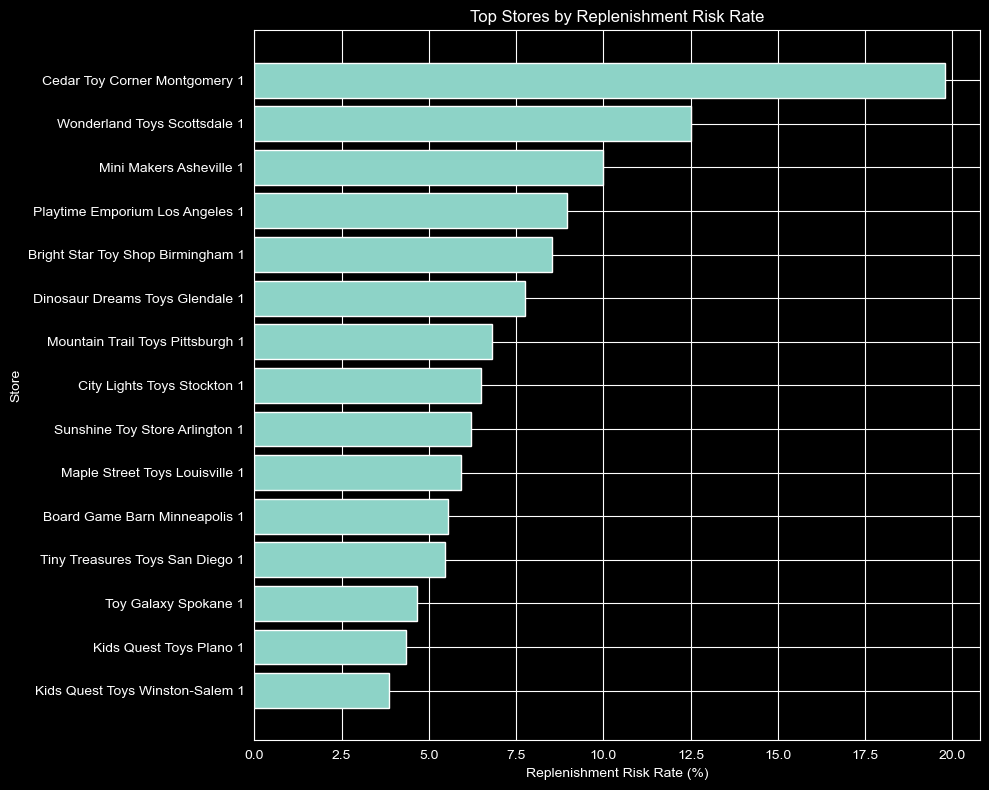

In [21]:
# Compare replenishment and overstock risk rates across stores
store_risk_plot = inventory_store.sort_values(
    "Replenishment_Risk_Rate",
    ascending=True
).tail(15)

plt.figure(figsize=(10, 8))

plt.barh(
    store_risk_plot["Store_Name"],
    store_risk_plot["Replenishment_Risk_Rate"]
)

plt.title("Top Stores by Replenishment Risk Rate")
plt.xlabel("Replenishment Risk Rate (%)")
plt.ylabel("Store")
plt.tight_layout()
plt.show()

In [22]:
# Calculate category-level inventory risk rates
inventory_category["Replenishment_Risk_Rate"] = (
    inventory_category["Replenishment_Risk_SKUs"] /
    inventory_category["Total_SKUs"] * 100
)
inventory_category["Overstock_Risk_Rate"] = (
    inventory_category["Overstock_Risk_SKUs"] /
    inventory_category["Total_SKUs"] * 100
)

# Rank categories by replenishment risk rate
category_replenishment_risk = inventory_category.sort_values(
    "Replenishment_Risk_Rate",
    ascending=False
)

print("Categories by replenishment risk rate:")
display(
    category_replenishment_risk[
        [
            "Product_Category",
            "Total_SKUs",
            "Replenishment_Risk_SKUs",
            "Replenishment_Risk_Rate",
            "Overstock_Risk_SKUs",
            "Overstock_Risk_Rate"
        ]
    ]
)

Categories by replenishment risk rate:


,Product_Category,Total_SKUs,Replenishment_Risk_SKUs,Replenishment_Risk_Rate,Overstock_Risk_SKUs,Overstock_Risk_Rate
4,Building Blocks,810,14,1.728395,21,2.592593
15,Collectibles,63,1,1.587302,2,3.174603
0,Toy Vehicles,1202,19,1.580699,36,2.995008
2,Baby & Toddler,1167,18,1.542416,40,3.427592
1,Arts & Crafts,1249,18,1.441153,43,3.442754
3,Outdoor Play,1055,14,1.327014,33,3.127962
7,Plush,693,9,1.298701,29,4.184704
5,Puzzles,1094,12,1.096892,44,4.021938
8,Board Games,885,9,1.016949,28,3.163842
13,Model Kits,479,4,0.835073,11,2.296451


In [23]:
# Rank categories by overstock risk rate
category_overstock_risk = inventory_category.sort_values(
    "Overstock_Risk_Rate",
    ascending=False
)

print("Categories by overstock risk rate:")
display(
    category_overstock_risk[
        [
            "Product_Category",
            "Total_SKUs",
            "Replenishment_Risk_SKUs",
            "Replenishment_Risk_Rate",
            "Overstock_Risk_SKUs",
            "Overstock_Risk_Rate"
        ]
    ]
)

Categories by overstock risk rate:


,Product_Category,Total_SKUs,Replenishment_Risk_SKUs,Replenishment_Risk_Rate,Overstock_Risk_SKUs,Overstock_Risk_Rate
11,Educational,915,4,0.437158,43,4.699454
7,Plush,693,9,1.298701,29,4.184704
5,Puzzles,1094,12,1.096892,44,4.021938
10,Dolls,844,6,0.710900,31,3.672986
14,Card Games,698,3,0.429799,25,3.581662
9,STEM Kits,869,7,0.805524,30,3.452244
1,Arts & Crafts,1249,18,1.441153,43,3.442754
2,Baby & Toddler,1167,18,1.542416,40,3.427592
15,Collectibles,63,1,1.587302,2,3.174603
8,Board Games,885,9,1.016949,28,3.163842


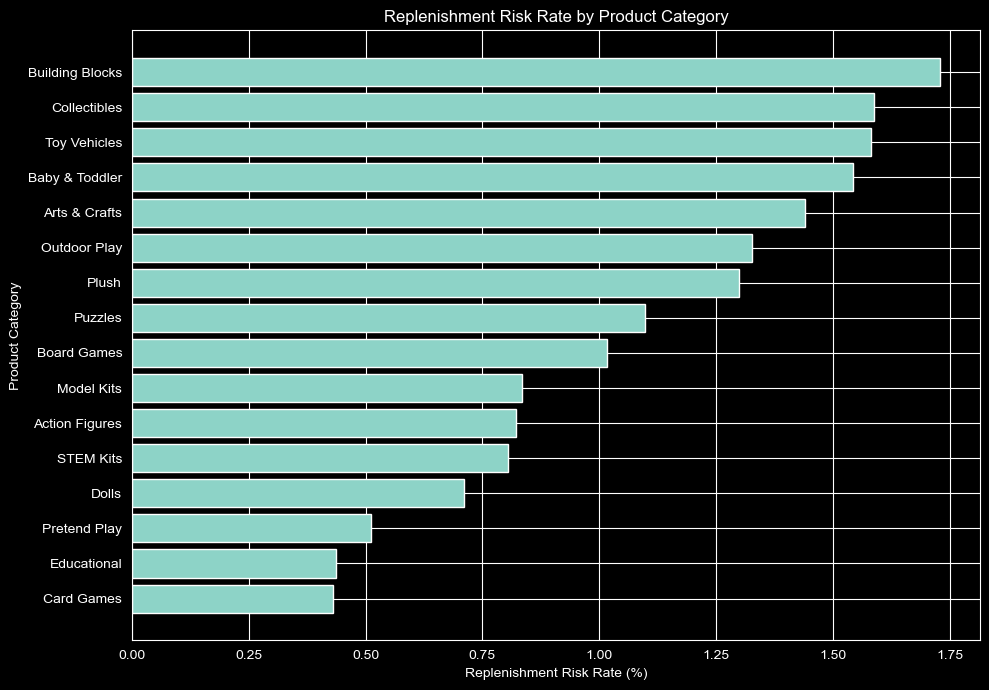

In [24]:
# Plot replenishment risk rate by product category
category_risk_plot = inventory_category.sort_values(
    "Replenishment_Risk_Rate",
    ascending=True
)

plt.figure(figsize=(10, 7))

plt.barh(
    category_risk_plot["Product_Category"],
    category_risk_plot["Replenishment_Risk_Rate"]
)

plt.title("Replenishment Risk Rate by Product Category")
plt.xlabel("Replenishment Risk Rate (%)")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()